Now, we will apply Ada Boost for Blood Cell Detection

In [1]:
#First, we will Normalize and Enhance all pictures
import cv2
import numpy as np
import matplotlib.pyplot as plt

def normalize_and_enhance(image):
    # 1. Chuyển sang không gian màu LAB để xử lý độ sáng mà không làm biến đổi màu sắc gốc
    lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)

    # 2. Áp dụng CLAHE để làm nổi bật các chi tiết mờ (như các phần đè lên nhau)
    # clipLimit cao (3.0-5.0) sẽ đẩy độ tương phản rất mạnh
    clahe = cv2.createCLAHE(clipLimit=4.0, tileGridSize=(8, 8))
    l = clahe.apply(l)

    # 3. Kéo giãn lược đồ (Min-Max Stretching) để chuẩn hóa độ đậm nhạt
    # Giúp ảnh nhạt trở nên đậm đà hơn
    l = cv2.normalize(l, None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX)

    # Gộp lại
    enhanced_lab = cv2.merge((l, a, b))
    enhanced_bgr = cv2.cvtColor(enhanced_lab, cv2.COLOR_LAB2BGR)

    # 4. Tăng độ bão hòa màu (Saturation) để các tế bào có màu đặc trưng hơn (tím/đỏ)
    hsv = cv2.cvtColor(enhanced_bgr, cv2.COLOR_BGR2HSV).astype("float32")
    (h, s, v) = cv2.split(hsv)
    
    # Nhân hệ số s (Saturation) để màu đậm lên, ví dụ 1.2 hoặc 1.5
    s = s * 1.3
    s = np.clip(s, 0, 255)
    
    hsv = cv2.merge([h, s, v])
    final_img = cv2.cvtColor(hsv.astype("uint8"), cv2.COLOR_HSV2BGR)

    return final_img

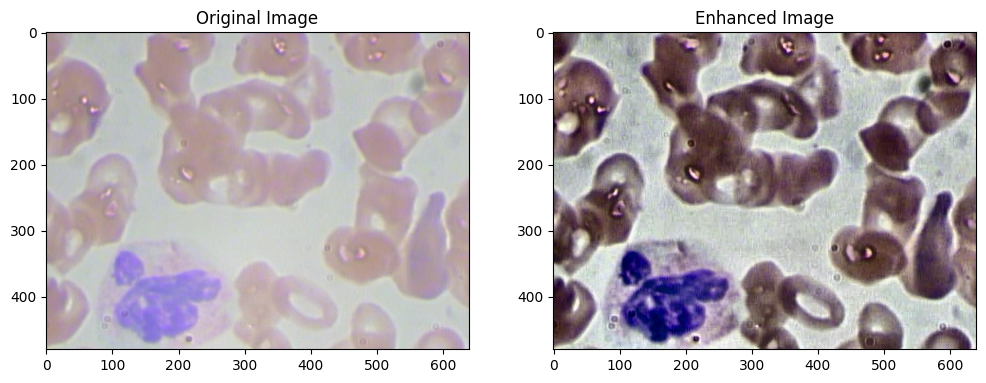

In [2]:
#Test function
#Use path dataset\BDDC\train\img\BloodImage_00001.jpeg
image_path = 'dataset/BDDC/train/img/BloodImage_00001.jpeg'
image = cv2.imread(image_path)
enhanced_image = normalize_and_enhance(image)
# Hiển thị ảnh gốc và ảnh đã được xử lý
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title('Original Image')
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.subplot(1, 2, 2)
plt.title('Enhanced Image')
plt.imshow(cv2.cvtColor(enhanced_image, cv2.COLOR_BGR2RGB))
plt.show()

In [3]:
#Use sliding window 64x64 and 128x128 with stride s to surf to all images.
#For each window, we will use Local Texture Features (like Viola-Jones)
#1. Local Binary Patterns (LBP)
#2. Histogram of Oriented Gradients (HOG)
#3. Haar-like Features
#4. Gabor Filters
import numpy as np
import cv2

from skimage.feature import (
    local_binary_pattern,
    hog,
    haar_like_feature,
    haar_like_feature_coord
)

# =========================
# LBP FEATURE
# =========================
def extract_lbp(window, radius=1, n_points=8):
    """
    Extract LBP histogram features
    """
    gray = cv2.cvtColor(window, cv2.COLOR_BGR2GRAY) if len(window.shape) == 3 else window
    lbp = local_binary_pattern(gray, P=n_points, R=radius, method="uniform")
    # Histogram
    hist, _ = np.histogram(lbp.ravel(), bins=np.arange(0, n_points + 3), range=(0, n_points + 2))
    hist = hist.astype("float")
    # Normalize
    hist /= (hist.sum() + 1e-6)
    return hist
# =========================
# HOG FEATURE
# =========================
def extract_hog(window):
    """
    Extract HOG features
    """
    gray = cv2.cvtColor(window, cv2.COLOR_BGR2GRAY) if len(window.shape) == 3 else window
    features = hog(gray, orientations=9, pixels_per_cell=(8, 8), cells_per_block=(2, 2), block_norm='L2-Hys', 
                   visualize=False, feature_vector=True)
    return features
# =========================
# HAAR FEATURE
# =========================
def extract_haar(window):
    """
    Extract Haar-like features
    """
    gray = cv2.cvtColor(window, cv2.COLOR_BGR2GRAY) if len(window.shape) == 3 else window
    # Resize nhỏ để tránh feature quá lớn
    gray = cv2.resize(gray, (32, 32))
    # Integral image
    ii = cv2.integral(gray)
    feature_types = [
        'type-2-x',
        'type-2-y',
        # 'type-3-x',
        # 'type-3-y',
        # 'type-4'
    ]
    # Generate coordinates
    feature_coord, feature_type = haar_like_feature_coord(width=32, height=32, feature_type=feature_types)
    # Giới hạn số feature để tránh vector quá lớn
    max_features = 10
    features = haar_like_feature(ii,0,0,32,32,
        feature_type=feature_type[:max_features],
        feature_coord=feature_coord[:max_features]
    )
    return np.array(features)
# =========================
# GABOR FEATURE
# =========================
def extract_gabor(window):
    """
    Extract Gabor filter responses
    """
    gray = cv2.cvtColor(window, cv2.COLOR_BGR2GRAY) if len(window.shape) == 3 else window
    features = []
    # Multiple orientations
    thetas = [0, np.pi / 4, np.pi / 2, 3 * np.pi / 4]
    for theta in thetas:
        kernel = cv2.getGaborKernel(ksize=(21, 21), sigma=5, theta=theta, lambd=10, gamma=0.5, psi=0, ktype=cv2.CV_32F)
        filtered = cv2.filter2D(gray, cv2.CV_8UC3, kernel)
        # Statistical features
        features.extend([filtered.mean(),filtered.std(), filtered.max()])
    return np.array(features)


# =========================
# COMBINE FEATURES
# =========================
def extract_features(image,window_size=(64, 64),stride=32):
    features = []
    boxes = []
    for y in range(0, image.shape[0] - window_size[1] + 1, stride):
        for x in range(0, image.shape[1] - window_size[0] + 1, stride):
            boxes.append((x,y,x+window_size[0],y+window_size[1]))
            window = image[y:y + window_size[1], x:x + window_size[0]]
            # Feature extraction
            lbp_features = extract_lbp(window)
            hog_features = extract_hog(window)
            #haar_features = extract_haar(window)
            gabor_features = extract_gabor(window)
            # Combine
            combined_features = np.hstack((lbp_features, hog_features, gabor_features))
            features.append(combined_features)
            #print("Done")
    return np.array(boxes), np.array(features)


In [4]:
#Now, we will use each feature like a week classifier
boxes, features = extract_features(image)


In [5]:
import numpy as np
import pandas as pd
import cv2
from pathlib import Path

def prepare_training_data(image_dir, annotation_csv, extract_feature, 
                           window_size=(64, 64), iou_threshold=0.5):
    """
    Tạo positive/negative samples từ ảnh và ground truth.
    """
    df = pd.read_csv(annotation_csv)
    
    X_pos, X_neg = [], []
    
    for img_path in Path(image_dir).glob("*.jpg"):  # hoặc *.png
        img = cv2.imread(str(img_path))
        img_name = img_path.name
        
        # Lấy ground truth boxes của ảnh này
        gt_boxes = df[df["filename"] == img_name][["xmin","ymin","xmax","ymax"]].values
        
        # --- POSITIVE: crop trực tiếp từ GT boxes ---
        for (xmin, ymin, xmax, ymax) in gt_boxes:
            patch = img[ymin:ymax, xmin:xmax]
            patch = cv2.resize(patch, window_size)
            feat = extract_feature(patch)
            X_pos.append(feat)
        
        # --- NEGATIVE: sliding window, lấy box có IoU thấp ---
        h, w = img.shape[:2]
        stride = window_size[0] // 2
        
        for y in range(0, h - window_size[1], stride):
            for x in range(0, w - window_size[0], stride):
                box = [x, y, x + window_size[0], y + window_size[1]]
                
                # Chỉ lấy nếu IoU với TẤT CẢ GT boxes đều thấp
                if max((compute_iou(box, gt) for gt in gt_boxes), default=0) < 0.3:
                    patch = img[y:y+window_size[1], x:x+window_size[0]]
                    feat = extract_feature(patch)
                    X_neg.append(feat)
    
    # Balance dataset (tránh class imbalance)
    np.random.shuffle(X_neg)
    X_neg = X_neg[:len(X_pos) * 3]  # ratio 1:3 pos:neg thường hiệu quả
    
    X = np.array(X_pos + X_neg)
    y = np.array([1]*len(X_pos) + [-1]*len(X_neg))  # AdaBoost dùng {-1, +1}
    
    return X, y


def compute_iou(boxA, boxB):
    """IoU giữa 2 boxes [xmin, ymin, xmax, ymax]."""
    xA = max(boxA[0], boxB[0]); yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2]); yB = min(boxA[3], boxB[3])
    
    inter = max(0, xB - xA) * max(0, yB - yA)
    areaA = (boxA[2]-boxA[0]) * (boxA[3]-boxA[1])
    areaB = (boxB[2]-boxB[0]) * (boxB[3]-boxB[1])
    
    return inter / (areaA + areaB - inter + 1e-6)

In [ ]:
# """
# Cascade AdaBoost - Blood Cell Detection
# Features: HOG + LBP + Gabor
# Classes : RBC, WBC, Platelet
# """

# import numpy as np
# import pandas as pd
# import cv2
# import joblib
# import os
# from pathlib import Path
# from sklearn.ensemble import AdaBoostClassifier
# from sklearn.tree import DecisionTreeClassifier
# from sklearn.metrics import classification_report, average_precision_score
# from sklearn.preprocessing import StandardScaler
# from tqdm import tqdm


# # ─────────────────────────────────────────────
# # 0. CẤU HÌNH CHUNG
# # ─────────────────────────────────────────────
# CLASSES        = ["rbc", "wbc", "platelets"]
# WINDOW_SIZE    = (64, 64)
# STRIDE         = 16
# IOU_POS        = 0.5
# IOU_NEG        = 0.3
# NEG_RATIO      = 3
# CASCADE_STAGES = [10, 30, 100]

# GABOR_PARAMS = [
#     {"ksize": 9, "sigma": 2.0, "theta": t, "lambd": 4.0, "gamma": 0.5}
#     for t in np.linspace(0, np.pi, 4, endpoint=False)
# ]


# # ─────────────────────────────────────────────
# # HELPER: in separator đẹp
# # ─────────────────────────────────────────────
# def _sep(char="─", n=52): print(char * n)
# def _header(title): _sep("═"); print(f"  {title}"); _sep("═")
# def _sub(title):    _sep("─"); print(f"  {title}"); _sep("─")


# # ─────────────────────────────────────────────
# # 1. FEATURE EXTRACTION
# # ─────────────────────────────────────────────
# def extract_hog(img_gray):
#     hog = cv2.HOGDescriptor(
#         _winSize     = WINDOW_SIZE,
#         _blockSize   = (16, 16),
#         _blockStride = (8, 8),
#         _cellSize    = (8, 8),
#         _nbins       = 9
#     )
#     return hog.compute(img_gray).flatten()


# def extract_lbp(img_gray, radius=1, n_points=8):
#     h, w = img_gray.shape
#     lbp_img = np.zeros((h, w), dtype=np.uint8)
#     for i, angle in enumerate(np.linspace(0, 2 * np.pi, n_points, endpoint=False)):
#         dx = radius * np.cos(angle)
#         dy = -radius * np.sin(angle)
#         neighbor = cv2.remap(
#             img_gray.astype(np.float32),
#             (np.tile(np.arange(w), (h, 1)) + dx).astype(np.float32),
#             (np.tile(np.arange(h), (w, 1)).T + dy).astype(np.float32),
#             cv2.INTER_LINEAR,
#             borderMode=cv2.BORDER_REFLECT
#         )
#         lbp_img += ((neighbor >= img_gray).astype(np.uint8) << i)
#     hist, _ = np.histogram(lbp_img.ravel(), bins=256, range=(0, 256))
#     return hist.astype(np.float32) / (hist.sum() + 1e-6)


# def extract_gabor(img_gray):
#     feats = []
#     for p in GABOR_PARAMS:
#         kernel = cv2.getGaborKernel(
#             (p["ksize"], p["ksize"]),
#             p["sigma"], p["theta"], p["lambd"], p["gamma"],
#             ktype=cv2.CV_32F
#         )
#         resp = cv2.filter2D(img_gray.astype(np.float32), cv2.CV_32F, kernel)
#         feats.extend([resp.mean(), resp.std()])
#     return np.array(feats, dtype=np.float32)


# def extract_feature(img_bgr):
#     img  = cv2.resize(img_bgr, WINDOW_SIZE)
#     gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
#     return np.concatenate([extract_hog(gray), extract_lbp(gray), extract_gabor(gray)])


# # ─────────────────────────────────────────────
# # 2. IoU
# # ─────────────────────────────────────────────
# def compute_iou(a, b):
#     xi1 = max(a[0], b[0]); yi1 = max(a[1], b[1])
#     xi2 = min(a[2], b[2]); yi2 = min(a[3], b[3])
#     inter = max(0, xi2 - xi1) * max(0, yi2 - yi1)
#     area_a = (a[2]-a[0]) * (a[3]-a[1])
#     area_b = (b[2]-b[0]) * (b[3]-b[1])
#     return inter / (area_a + area_b - inter + 1e-6)


# # ─────────────────────────────────────────────
# # 3. DATA LOADER  ← LOG: kiểm tra CSV & ảnh
# # ─────────────────────────────────────────────
# def load_annotations(csv_path):
#     _sub(f"Load annotations: {csv_path}")
#     df = pd.read_csv(csv_path)
#     df.columns = df.columns.str.strip().str.lower()

#     # ── LOG: cột có trong CSV ──────────────────
#     print(f"  Columns  : {list(df.columns)}")
#     print(f"  Rows     : {len(df)}")
#     print(f"  Labels   : {sorted(df['label'].unique())}")

#     # ── LOG: phân phối label ───────────────────
#     dist = df['label'].value_counts()
#     for lbl, cnt in dist.items():
#         print(f"    {lbl:<14}: {cnt:>5} boxes")

#     ann = {}
#     for _, row in df.iterrows():
#         fname = row["image"]
#         box = (int(row["xmin"]), int(row["ymin"]),
#                int(row["xmax"]), int(row["ymax"]),
#                str(row["label"]).strip())
#         ann.setdefault(fname, []).append(box)

#     print(f"  Images with annotation: {len(ann)}")
#     return ann


# def prepare_samples(image_dir, ann_dict, target_class, stride=STRIDE):
#     _sub(f"Prepare samples  class='{target_class}'  dir={image_dir}")

#     img_paths = (list(Path(image_dir).glob("*.jpg"))  +
#                  list(Path(image_dir).glob("*.png"))  +
#                  list(Path(image_dir).glob("*.jpeg")))
#     print(f"  Ảnh tìm thấy trong thư mục: {len(img_paths)}")

#     # ── LOG: kiểm tra khớp annotation ↔ disk ──
#     ann_fnames  = set(ann_dict.keys())
#     disk_fnames = {p.name + '.png' for p in img_paths}
#     matched     = ann_fnames & disk_fnames
#     only_ann    = ann_fnames - disk_fnames
#     only_disk   = disk_fnames - ann_fnames
#     print(f"  Ảnh khớp annotation ↔ disk : {len(matched)}")
#     if only_ann:
#         print(f"  ⚠ Trong CSV nhưng KHÔNG có file  : {len(only_ann)} "
#               f"(ví dụ: {list(only_ann)[:3]})")
#     if only_disk:
#         print(f"  ⚠ Có file nhưng KHÔNG có annotation: {len(only_disk)} "
#               f"(ví dụ: {list(only_disk)[:3]})")

#     X_pos, X_neg = [], []
#     n_img_no_ann = 0

#     for img_path in tqdm(img_paths, desc=f"  [{target_class}]"):
#         img = cv2.imread(str(img_path))
#         if img is None:
#             print(f"  ⚠ Không đọc được ảnh: {img_path.name}")
#             continue
#         h, w  = img.shape[:2]
#         fname = img_path.name + ".png"
#         boxes = ann_dict.get(fname, [])
#         if not boxes:
#             n_img_no_ann += 1

#         gt_all = [(b[0],b[1],b[2],b[3]) for b in boxes]
#         gt_cls = [(b[0],b[1],b[2],b[3]) for b in boxes if b[4] == target_class]

#         # POSITIVE
#         for (xmin, ymin, xmax, ymax) in gt_cls:
#             xmin = max(0, xmin); ymin = max(0, ymin)
#             xmax = min(w, xmax); ymax = min(h, ymax)
#             if xmax <= xmin or ymax <= ymin:
#                 continue
#             patch = img[ymin:ymax, xmin:xmax]
#             X_pos.append(extract_feature(patch))

#         # NEGATIVE (sliding window)
#         ww, wh = WINDOW_SIZE
#         for y in range(0, h - wh, stride):
#             for x in range(0, w - ww, stride):
#                 win = [x, y, x+ww, y+wh]
#                 max_iou = max((compute_iou(win, gt) for gt in gt_all), default=0.0)
#                 if max_iou < IOU_NEG:
#                     patch = img[y:y+wh, x:x+ww]
#                     X_neg.append(extract_feature(patch))

#     # ── LOG: tổng kết sampling ─────────────────
#     print(f"\n  Ảnh không có annotation nào : {n_img_no_ann}")
#     print(f"  Positive (trước balance)     : {len(X_pos)}")
#     print(f"  Negative (trước balance)     : {len(X_neg)}")

#     if len(X_pos) == 0:
#         raise ValueError(f"Không có positive nào cho '{target_class}'. "
#                          f"Kiểm tra tên class trong CSV.")

#     np.random.shuffle(X_neg)
#     X_neg = X_neg[:len(X_pos) * NEG_RATIO]

#     X = np.array(X_pos + X_neg, dtype=np.float32)
#     y = np.array([1]*len(X_pos) + [-1]*len(X_neg), dtype=np.int8)

#     # ── LOG: kiểm tra feature discriminability ─
#     print(f"  Positive (sau balance)       : {len(X_pos)}")
#     print(f"  Negative (sau balance)       : {len(X_neg)}")
#     print(f"  Feature dim                  : {X.shape[1]}")
#     print(f"  Feature mean (pos) : {X[y== 1].mean():.4f}  std: {X[y== 1].std():.4f}")
#     print(f"  Feature mean (neg) : {X[y==-1].mean():.4f}  std: {X[y==-1].std():.4f}")

#     mean_diff = abs(X[y==1].mean() - X[y==-1].mean())
#     if mean_diff < 0.01:
#         print(f"  ⚠ CẢNH BÁO: mean pos & neg rất gần nhau "
#               f"(diff={mean_diff:.5f}) → feature có thể không discriminative!")
#     else:
#         print(f"  ✓ mean diff pos vs neg: {mean_diff:.4f}")

#     return X, y


# # ─────────────────────────────────────────────
# # 4. CASCADE ADABOOST  ← LOG: mỗi stage + score dist
# # ─────────────────────────────────────────────
# class CascadeAdaBoost:

#     def __init__(self, stages=CASCADE_STAGES):
#         self.stages  = stages
#         self.models  = []
#         self.scalers = []
#         self.tprs    = []

#     def fit(self, X, y, target_fpr=0.5):
#         mask = np.ones(len(y), dtype=bool)

#         for stage_idx, n_est in enumerate(self.stages):
#             X_s = X[mask]; y_s = y[mask]
#             n_pos = (y_s == 1).sum(); n_neg = (y_s == -1).sum()

#             _sub(f"Stage {stage_idx+1}/{len(self.stages)}  "
#                  f"estimators={n_est}  pos={n_pos}  neg={n_neg}")

#             # ── LOG: kiểm tra class balance ───────
#             ratio = n_neg / (n_pos + 1e-6)
#             if ratio > 10:
#                 print(f"  ⚠ Imbalance nặng : neg/pos = {ratio:.1f}x")
#             elif ratio < 0.5:
#                 print(f"  ⚠ Quá ít negative: neg/pos = {ratio:.1f}x")
#             else:
#                 print(f"  ✓ Ratio neg/pos  = {ratio:.1f}x")

#             scaler   = StandardScaler()
#             X_scaled = scaler.fit_transform(X_s)

#             clf = AdaBoostClassifier(
#                 estimator    = DecisionTreeClassifier(max_depth=1),
#                 n_estimators = n_est,
#                 learning_rate= 0.5,
#                 random_state = 42
#             )
#             clf.fit(X_scaled, y_s)

#             scores_train = clf.decision_function(X_scaled)
#             pos_scores   = scores_train[y_s ==  1]
#             neg_scores   = scores_train[y_s == -1]
#             threshold    = np.percentile(pos_scores, 1)

#             # ── LOG: phân phối score + separation ─
#             print(f"\n  Score distribution (train):")
#             print(f"    Positive → min:{pos_scores.min():7.3f}  "
#                   f"mean:{pos_scores.mean():7.3f}  max:{pos_scores.max():7.3f}")
#             print(f"    Negative → min:{neg_scores.min():7.3f}  "
#                   f"mean:{neg_scores.mean():7.3f}  max:{neg_scores.max():7.3f}")
#             print(f"    Threshold (1st pct pos)    : {threshold:.3f}")

#             overlap = (neg_scores >= threshold).mean()
#             sep     = pos_scores.mean() - neg_scores.mean()
#             print(f"    Neg vượt threshold (hard %) : {overlap*100:.1f}%")

#             if sep < 0.5:
#                 print(f"  ⚠ Separation thấp (pos_mean - neg_mean = {sep:.3f}) "
#                       f"→ feature chưa phân tách tốt hoặc cần thêm estimators")
#             else:
#                 print(f"  ✓ Separation = {sep:.3f}")

#             self.models.append(clf)
#             self.scalers.append(scaler)
#             self.tprs.append(threshold)

#             # Cập nhật mask
#             all_scaled = scaler.transform(X)
#             all_scores = clf.decision_function(all_scaled)
#             pass_stage = all_scores >= threshold

#             hard_neg  = (y == -1) & pass_stage
#             all_pos   = (y ==  1)
#             mask      = hard_neg | all_pos

#             n_rejected = ((y == -1) & ~pass_stage).sum()
#             tpr_train  = pass_stage[y == 1].mean()

#             # ── LOG: TPR + rejected summary ───────
#             print(f"\n  Rejected negatives : {n_rejected}")
#             print(f"  Hard negatives left: {hard_neg.sum()}")
#             print(f"  TPR (pos kept)     : {tpr_train*100:.1f}%", end="")
#             if tpr_train < 0.95:
#                 print(f"  ⚠ TPR thấp! Model đang mất positive "
#                       f"→ giảm percentile trong threshold")
#             else:
#                 print("  ✓")

#             if hard_neg.sum() < 5:
#                 print("\n  → Hầu hết negative đã bị loại. Dừng cascade sớm.")
#                 break

#         _sub(f"Cascade hoàn tất: {len(self.models)} stage(s)")

#     def predict(self, X):
#         labels = np.ones(len(X), dtype=int)
#         for clf, scaler, thr in zip(self.models, self.scalers, self.tprs):
#             scores = clf.decision_function(scaler.transform(X))
#             labels[scores < thr] = -1
#         return labels

#     def decision_function(self, X):
#         total = np.zeros(len(X))
#         for clf, scaler, _ in zip(self.models, self.scalers, self.tprs):
#             total += clf.decision_function(scaler.transform(X))
#         return total

#     def save(self, path):
#         joblib.dump({"models": self.models, "scalers": self.scalers,
#                      "tprs": self.tprs, "stages": self.stages}, path)
#         print(f"  Đã lưu: {path}")

#     @classmethod
#     def load(cls, path):
#         data = joblib.load(path)
#         obj = cls(stages=data["stages"])
#         obj.models  = data["models"]
#         obj.scalers = data["scalers"]
#         obj.tprs    = data["tprs"]
#         return obj


# # ─────────────────────────────────────────────
# # 5. TRAIN PIPELINE  ← LOG: val report + TP/FP/FN
# # ─────────────────────────────────────────────
# def train_all(train_image_dir, train_csv,
#               val_image_dir,   val_csv,
#               save_dir="models"):
#     os.makedirs(save_dir, exist_ok=True)
#     train_ann = load_annotations(train_csv)
#     val_ann   = load_annotations(val_csv)
#     detectors = {}

#     for cls in CLASSES:
#         _header(f"TRAINING CLASS: {cls.upper()}")

#         X_train, y_train = prepare_samples(train_image_dir, train_ann, cls)

#         cascade = CascadeAdaBoost(stages=CASCADE_STAGES)
#         cascade.fit(X_train, y_train)

#         # ── LOG: validation ───────────────────────
#         _sub(f"Validation  class='{cls}'")
#         X_val, y_val = prepare_samples(val_image_dir, val_ann, cls)
#         y_pred = cascade.predict(X_val)

#         print(classification_report(y_val, y_pred,
#                                     target_names=["background", cls]))

#         # ── LOG: val score distribution ───────────
#         val_scores = cascade.decision_function(X_val)
#         pos_s = val_scores[y_val ==  1]
#         neg_s = val_scores[y_val == -1]
#         print(f"  Val score (pos): mean={pos_s.mean():.3f}  std={pos_s.std():.3f}")
#         print(f"  Val score (neg): mean={neg_s.mean():.3f}  std={neg_s.std():.3f}")

#         # ── LOG: phân tích FP / FN + gợi ý fix ───
#         fp = ((y_pred ==  1) & (y_val == -1)).sum()
#         fn = ((y_pred == -1) & (y_val ==  1)).sum()
#         tp = ((y_pred ==  1) & (y_val ==  1)).sum()
#         tn = ((y_pred == -1) & (y_val == -1)).sum()
#         print(f"\n  TP={tp}  TN={tn}  FP={fp}  FN={fn}")
#         if fn > tp * 0.2:
#             print(f"  ⚠ FN cao ({fn}) → model bỏ sót nhiều object thật "
#                   f"→ giảm percentile threshold (hiện 1%) hoặc tăng NEG_RATIO")
#         if fp > tn * 0.3:
#             print(f"  ⚠ FP cao ({fp}) → báo nhầm nhiều background "
#                   f"→ thêm hard negative mining hoặc thêm stage")

#         model_path = os.path.join(save_dir, f"cascade_{cls}.pkl")
#         cascade.save(model_path)
#         detectors[cls] = cascade

#     return detectors


# # ─────────────────────────────────────────────
# # 6. NMS
# # ─────────────────────────────────────────────
# def nms(detections, iou_threshold=0.3):
#     if not detections:
#         return []
#     detections = sorted(detections, key=lambda d: d[0], reverse=True)
#     kept = []
#     while detections:
#         best = detections.pop(0)
#         kept.append(best)
#         detections = [d for d in detections
#                       if d[1] != best[1] or
#                          compute_iou(best[2], d[2]) < iou_threshold]
#     return kept


# # ─────────────────────────────────────────────
# # 7. INFERENCE
# # ─────────────────────────────────────────────
# def detect_image(img_bgr, detectors, stride=STRIDE, nms_iou=0.3):
#     h, w   = img_bgr.shape[:2]
#     ww, wh = WINDOW_SIZE
#     windows, feats = [], []

#     for y in range(0, h - wh, stride):
#         for x in range(0, w - ww, stride):
#             windows.append([x, y, x+ww, y+wh])
#             feats.append(extract_feature(img_bgr[y:y+wh, x:x+ww]))

#     feat_matrix = np.array(feats, dtype=np.float32)
#     detections  = []

#     for cls, cascade in detectors.items():
#         scores = cascade.decision_function(feat_matrix)
#         preds  = cascade.predict(feat_matrix)
#         for i, (pred, score) in enumerate(zip(preds, scores)):
#             if pred == 1:
#                 detections.append((float(score), cls, windows[i]))

#     return nms(detections, iou_threshold=nms_iou)


# # ─────────────────────────────────────────────
# # 8. EVALUATE  ← LOG: AP + recall + gợi ý fix
# # ─────────────────────────────────────────────
# def evaluate_test(test_image_dir, test_csv, detectors, iou_threshold=0.5):
#     _header("EVALUATE ON TEST SET")
#     test_ann  = load_annotations(test_csv)
#     img_paths = (list(Path(test_image_dir).glob("*.jpeg")) +
#                  list(Path(test_image_dir).glob("*.jpg"))  +
#                  list(Path(test_image_dir).glob("*.png")))
#     print(f"  Test images: {len(img_paths)}")

#     per_class = {cls: {"scores": [], "tp": [], "n_gt": 0} for cls in CLASSES}

#     for img_path in tqdm(img_paths, desc="  Evaluating"):
#         img = cv2.imread(str(img_path))
#         if img is None: continue
#         fname  = img_path.name
#         gt_all = test_ann.get(fname, [])

#         gt_by_class = {cls: [(b[0],b[1],b[2],b[3]) for b in gt_all if b[4]==cls]
#                        for cls in CLASSES}
#         matched = {cls: set() for cls in CLASSES}

#         for cls in CLASSES:
#             per_class[cls]["n_gt"] += len(gt_by_class[cls])

#         preds = detect_image(img, detectors)

#         for score, cls, box in sorted(preds, key=lambda x: -x[0]):
#             gt_list = gt_by_class.get(cls, [])
#             best_iou, best_idx = 0, -1
#             for i, gt in enumerate(gt_list):
#                 iou = compute_iou(box, gt)
#                 if iou > best_iou:
#                     best_iou, best_idx = iou, i

#             is_tp = int(best_iou >= iou_threshold and best_idx not in matched[cls])
#             if is_tp:
#                 matched[cls].add(best_idx)

#             per_class[cls]["scores"].append(score)
#             per_class[cls]["tp"].append(is_tp)

#     # ── LOG: kết quả AP + chẩn đoán ──────────
#     _sub("Results")
#     print(f"  {'Class':<12} {'AP':>7} {'n_GT':>7} {'n_Pred':>7} {'Recall':>8}  Note")
#     print(f"  {'-'*62}")
#     aps = []
#     for cls in CLASSES:
#         d      = per_class[cls]
#         n_pred = len(d["scores"])
#         if n_pred == 0:
#             print(f"  {cls:<12} {'N/A':>7} {d['n_gt']:>7} {0:>7}  "
#                   f"⚠ Không detect được gì!")
#             continue

#         scores = np.array(d["scores"])
#         tp_arr = np.array(d["tp"])
#         order  = np.argsort(-scores)
#         tp_cum = np.cumsum(tp_arr[order])
#         fp_cum = np.cumsum(1 - tp_arr[order])
#         precision  = tp_cum / (tp_cum + fp_cum + 1e-6)
#         recall     = tp_cum / (d["n_gt"] + 1e-6)
#         ap         = np.trapezoid(precision, recall)
#         max_recall = recall[-1]
#         aps.append(ap)

#         note = ("⚠ AP thấp"       if ap < 0.3 else
#                 "△ AP trung bình" if ap < 0.6 else "✓ Tốt")
#         if max_recall < 0.5:
#             note += " | recall thấp → FN nhiều"

#         print(f"  {cls:<12} {ap:>7.4f} {d['n_gt']:>7} {n_pred:>7} "
#               f"{max_recall:>8.3f}  {note}")

#     if aps:
#         print(f"\n  mAP: {np.mean(aps):.4f}")
#     _sep("═")


# # ─────────────────────────────────────────────
# # 9. VISUALIZE
# # ─────────────────────────────────────────────
# CLASS_COLORS = {"rbc": (0,255,0), "wbc": (255,128,0), "platelets": (0,128,255)}

# def visualize(img_bgr, detections, save_path=None):
#     vis = img_bgr.copy()
#     for score, cls, (x1,y1,x2,y2) in detections:
#         color = CLASS_COLORS.get(cls, (255,255,255))
#         cv2.rectangle(vis, (x1,y1), (x2,y2), color, 2)
#         label = f"{cls} {score:.1f}"
#         (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.45, 1)
#         cv2.rectangle(vis, (x1, y1-th-4), (x1+tw, y1), color, -1)
#         cv2.putText(vis, label, (x1, y1-3),
#                     cv2.FONT_HERSHEY_SIMPLEX, 0.45, (0,0,0), 1)
#     if save_path:
#         cv2.imwrite(save_path, vis)
#     return vis


# # ─────────────────────────────────────────────
# # 10. MAIN
# # ─────────────────────────────────────────────
# if __name__ == "__main__":
#     TRAIN_IMG = "dataset/BDDC/train/img"
#     TRAIN_CSV = "dataset/BDDC/annotations_train.csv"
#     VAL_IMG   = "dataset/BDDC/val/img"
#     VAL_CSV   = "dataset/BDDC/annotations_eval.csv"
#     TEST_IMG  = "dataset/BDDC/test/img"
#     TEST_CSV  = "dataset/BDDC/annotations_test.csv"
#     MODEL_DIR = "models"

#     detectors = train_all(TRAIN_IMG, TRAIN_CSV, VAL_IMG, VAL_CSV, save_dir=MODEL_DIR)
#     evaluate_test(TEST_IMG, TEST_CSV, detectors)

#     test_img_path = next(Path(TEST_IMG).glob("*.jpeg"), None)
#     if test_img_path:
#         img  = cv2.imread(str(test_img_path))
#         dets = detect_image(img, detectors)
#         visualize(img, dets, save_path="result.jpg")
#         _sub(f"Demo: {len(dets)} detections → result.jpg")

#     # loaded = {cls: CascadeAdaBoost.load(f"models/cascade_{cls}.pkl")
#     #           for cls in CLASSES}

In [7]:
"""
Cascade AdaBoost - Blood Cell Detection
Improved Version:
- Class-specific window size
- Shape features
- Better Gabor statistics
- Better HOG config
"""

import numpy as np
import pandas as pd
import cv2
import joblib
import os

from pathlib import Path
from tqdm import tqdm

from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report


# =========================================================
# CONFIG
# =========================================================

CLASSES = ["rbc", "wbc", "platelets"]
CLASS_CONFIG = {
    "rbc": {
        "window_size": (100, 100),
        "stride": 25,          # 100 // 4
        "padding": 0.15
    },
    "wbc": {
        "window_size": (200, 200),
        "stride": 50,          # 200 // 4
        "padding": 0.10
    },
    "platelets": {
        "window_size": (32, 32),
        "stride": 8,           # 32 // 4
        "padding": 0.05
    }
}

IOU_POS        = 0.5
IOU_NEG        = 0.3
NEG_RATIO      = 3

CASCADE_STAGES = [10, 30, 100]

GABOR_PARAMS = [
    {
        "ksize": 9,
        "sigma": 2.0,
        "theta": t,
        "lambd": 4.0,
        "gamma": 0.5
    }
    for t in np.linspace(0, np.pi, 4, endpoint=False)
]


# =========================================================
# PRETTY PRINT
# =========================================================

def _sep(char="─", n=60):
    print(char * n)

def _header(title):
    _sep("═")
    print(f"  {title}")
    _sep("═")

def _sub(title):
    _sep("─")
    print(f"  {title}")
    _sep("─")


# =========================================================
# FEATURE EXTRACTION
# =========================================================

def extract_hog(img_gray, window_size):

    h, w = window_size

    hog = cv2.HOGDescriptor(
        _winSize     = (w, h),
        _blockSize   = (8, 8),
        _blockStride = (4, 4),
        _cellSize    = (4, 4),
        _nbins       = 9
    )

    return hog.compute(img_gray).flatten()


def extract_lbp(img_gray, radius=1, n_points=8):

    h, w = img_gray.shape

    lbp_img = np.zeros((h, w), dtype=np.uint8)

    for i, angle in enumerate(
        np.linspace(0, 2*np.pi, n_points, endpoint=False)
    ):

        dx = radius * np.cos(angle)
        dy = -radius * np.sin(angle)

        neighbor = cv2.remap(
            img_gray.astype(np.float32),

            (np.tile(np.arange(w), (h,1)) + dx).astype(np.float32),

            (np.tile(np.arange(h), (w,1)).T + dy).astype(np.float32),

            cv2.INTER_LINEAR,
            borderMode=cv2.BORDER_REFLECT
        )

        lbp_img += ((neighbor >= img_gray).astype(np.uint8) << i)

    hist, _ = np.histogram(
        lbp_img.ravel(),
        bins=256,
        range=(0,256)
    )

    hist = hist.astype(np.float32)

    hist /= (hist.sum() + 1e-6)

    return hist


def extract_gabor(img_gray):

    feats = []

    for p in GABOR_PARAMS:

        kernel = cv2.getGaborKernel(
            (p["ksize"], p["ksize"]),
            p["sigma"],
            p["theta"],
            p["lambd"],
            p["gamma"],
            ktype=cv2.CV_32F
        )

        resp = cv2.filter2D(
            img_gray.astype(np.float32),
            cv2.CV_32F,
            kernel
        )

        feats.extend([
            resp.mean(),
            resp.std(),
            np.percentile(resp, 10),
            np.percentile(resp, 25),
            np.percentile(resp, 50),
            np.percentile(resp, 75),
            np.percentile(resp, 90)
        ])

    return np.array(feats, dtype=np.float32)


def extract_shape_features(img_gray):

    blur = cv2.GaussianBlur(img_gray, (3,3), 0)

    _, thresh = cv2.threshold(
        blur,
        0,
        255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    contours, _ = cv2.findContours(
        thresh,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    if len(contours) == 0:
        return np.zeros(8, dtype=np.float32)

    cnt = max(contours, key=cv2.contourArea)

    area = cv2.contourArea(cnt)

    perimeter = cv2.arcLength(cnt, True)

    if perimeter < 1e-6:
        perimeter = 1e-6

    x, y, w, h = cv2.boundingRect(cnt)

    aspect_ratio = w / (h + 1e-6)

    circularity = (4 * np.pi * area) / (
        perimeter * perimeter + 1e-6
    )

    hull = cv2.convexHull(cnt)

    hull_area = cv2.contourArea(hull)

    solidity = area / (hull_area + 1e-6)

    extent = area / (w * h + 1e-6)

    ellipse_ecc = 0.0

    if len(cnt) >= 5:

        (_, _), (MA, ma), _ = cv2.fitEllipse(cnt)

        if ma > 1e-6:

            ellipse_ecc = np.sqrt(
                1.0 - (MA * MA) / (ma * ma + 1e-6)
            )

    hu = cv2.HuMoments(
        cv2.moments(cnt)
    ).flatten()

    shape_feats = np.array([
        area,
        perimeter,
        aspect_ratio,
        circularity,
        solidity,
        extent,
        ellipse_ecc,
        hu[0]
    ], dtype=np.float32)

    return shape_feats


def extract_feature(img_bgr, target_size):

    img = cv2.resize(img_bgr, target_size)

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    hog_feat   = extract_hog(gray, target_size)
    lbp_feat   = extract_lbp(gray)
    gabor_feat = extract_gabor(gray)
    shape_feat = extract_shape_features(gray)

    return np.concatenate([
        hog_feat,
        lbp_feat,
        gabor_feat,
        shape_feat
    ])


# =========================================================
# IOU
# =========================================================

def compute_iou(a, b):

    xi1 = max(a[0], b[0])
    yi1 = max(a[1], b[1])

    xi2 = min(a[2], b[2])
    yi2 = min(a[3], b[3])

    inter = max(0, xi2-xi1) * max(0, yi2-yi1)

    area_a = (a[2]-a[0]) * (a[3]-a[1])
    area_b = (b[2]-b[0]) * (b[3]-b[1])

    return inter / (area_a + area_b - inter + 1e-6)


# =========================================================
# LOAD ANNOTATIONS
# =========================================================

def load_annotations(csv_path):

    _sub(f"Load annotations: {csv_path}")

    df = pd.read_csv(csv_path)

    # Chuẩn hóa tên cột
    df.columns = df.columns.str.strip().str.lower()

    print(f"  Columns  : {list(df.columns)}")
    print(f"  Rows     : {len(df)}")
    print(f"  Labels   : {sorted(df['label'].unique())}")

    # Đếm số box theo từng class
    label_counts = df['label'].value_counts()
    for lbl in sorted(label_counts.index):
        print(f"    {lbl:12} : {label_counts[lbl]:5d} boxes")

    ann = {}
    for _, row in df.iterrows():
        fname = row["image"]
        box = (
            int(row["xmin"]),
            int(row["ymin"]),
            int(row["xmax"]),
            int(row["ymax"]),
            str(row["label"]).strip()
        )
        ann.setdefault(fname, []).append(box)

    print(f"  Images with annotation: {len(ann)}")
    return ann


# =========================================================
# PREPARE SAMPLES
# =========================================================

# =========================================================
# PREPARE SAMPLES (FIXED)
# =========================================================

def prepare_samples(image_dir, ann_dict, target_class):

    cfg = CLASS_CONFIG[target_class]
    ww, wh = cfg["window_size"]
    stride = cfg["stride"]
    padding = cfg["padding"]

    _sub(f"Prepare samples  class='{target_class}'  dir={image_dir}")

    img_paths = (
        list(Path(image_dir).glob("*.jpg")) +
        list(Path(image_dir).glob("*.png")) +
        list(Path(image_dir).glob("*.jpeg"))
    )

    matched_count = 0
    no_anno_count = 0
    for p in img_paths:
        key = p.name + '.png'
        if ann_dict.get(key) is not None:
            matched_count += 1
        else:
            no_anno_count += 1

    print(f"  Ảnh tìm thấy trong thư mục: {len(img_paths)}")
    print(f"  Ảnh khớp annotation ↔ disk : {matched_count}")
    print(f"  Ảnh không có annotation nào : {no_anno_count}")

    X_pos = []
    X_neg = []

    for img_path in tqdm(img_paths, desc=f"[{target_class}]"):

        img = cv2.imread(str(img_path))
        if img is None:
            continue

        h, w = img.shape[:2]
        fname = img_path.name + '.png'
        boxes = ann_dict.get(fname, [])

        gt_all = [(b[0], b[1], b[2], b[3]) for b in boxes]
        gt_cls = [(b[0], b[1], b[2], b[3]) for b in boxes if b[4] == target_class]

        
        # ----- POSITIVE -----
        for (xmin, ymin, xmax, ymax) in gt_cls:
            pad = int(max(xmax - xmin, ymax - ymin) * padding)
            x1 = max(0, xmin - pad)
            y1 = max(0, ymin - pad)
            x2 = min(w, xmax + pad)
            y2 = min(h, ymax + pad)

            # Kiểm tra vùng hợp lệ
            if x2 <= x1 or y2 <= y1:
                print(f"  ⚠ Bỏ qua patch không hợp lệ: ({x1},{y1},{x2},{y2}) từ {img_path.name}")
                continue

            patch = img[y1:y2, x1:x2]
            # Kiểm tra patch không rỗng
            if patch.size == 0:
                continue

            feat = extract_feature(patch, cfg["window_size"])
            X_pos.append(feat)

        # ----- NEGATIVE -----
        for y in range(0, h - wh, stride):
            for x in range(0, w - ww, stride):
                win = [x, y, x + ww, y + wh]
                max_iou = max((compute_iou(win, gt) for gt in gt_all), default=0.0)
                if max_iou < IOU_NEG:
                    patch = img[y:y+wh, x:x+ww]
                    if patch.size == 0:
                        continue
                    feat = extract_feature(patch, cfg["window_size"])
                    X_neg.append(feat)

    print(f"  Positive (trước balance)     : {len(X_pos)}")
    print(f"  Negative (trước balance)     : {len(X_neg)}")

    np.random.shuffle(X_neg)
    X_neg = X_neg[:len(X_pos) * NEG_RATIO]

    if len(X_pos) > 0:
        pos_arr = np.array(X_pos)
        pos_mean = pos_arr.mean()
        pos_std = pos_arr.std()
    else:
        pos_mean = pos_std = 0.0

    if len(X_neg) > 0:
        neg_arr = np.array(X_neg)
        neg_mean = neg_arr.mean()
        neg_std = neg_arr.std()
    else:
        neg_mean = neg_std = 0.0

    print(f"  Positive (sau balance)       : {len(X_pos)}")
    print(f"  Negative (sau balance)       : {len(X_neg)}")
    print(f"  Feature dim                  : {len(X_pos[0]) if X_pos else 0}")
    print(f"  Feature mean (pos) : {pos_mean:.4f}  std: {pos_std:.4f}")
    print(f"  Feature mean (neg) : {neg_mean:.4f}  std: {neg_std:.4f}")

    diff = abs(pos_mean - neg_mean)
    if diff < 0.01:
        print(f"  ⚠ CẢNH BÁO: mean pos & neg rất gần nhau (diff={diff:.5f}) → feature có thể không discriminative!")

    X = np.array(X_pos + X_neg, dtype=np.float32)
    y = np.array([1]*len(X_pos) + [-1]*len(X_neg), dtype=np.int8)

    return X, y


# =========================================================
# CASCADE
# =========================================================

class CascadeAdaBoost:

    def __init__(self, stages=CASCADE_STAGES):
        self.stages  = stages
        self.models  = []
        self.scalers = []
        self.tprs    = []

    def fit(self, X, y):

        mask = np.ones(len(y), dtype=bool)
        total_neg_initial = (y == -1).sum()

        for stage_idx, n_est in enumerate(self.stages):

            X_s = X[mask]
            y_s = y[mask]

            pos_s = (y_s == 1).sum()
            neg_s = (y_s == -1).sum()
            ratio = neg_s / pos_s if pos_s > 0 else 0

            _sep("─")
            print(f"  Stage {stage_idx+1}/{len(self.stages)}  estimators={n_est}  pos={pos_s}  neg={neg_s}")
            if ratio >= 1:
                print(f"  ✓ Ratio neg/pos  = {ratio:.1f}x")
            else:
                print(f"  ⚠ Quá ít negative: neg/pos = {ratio:.1f}x")

            # Train stage
            scaler = StandardScaler()
            X_scaled = scaler.fit_transform(X_s)
            clf = AdaBoostClassifier(
                estimator=DecisionTreeClassifier(max_depth=1),
                n_estimators=n_est,
                learning_rate=0.5,
                random_state=42
            )
            clf.fit(X_scaled, y_s)

            # Đánh giá trên tập train của stage
            scores = clf.decision_function(X_scaled)
            pos_scores = scores[y_s == 1]
            neg_scores = scores[y_s == -1]

            print(f"\n  Score distribution (train):")
            print(f"    Positive → min: {pos_scores.min():6.3f}  mean: {pos_scores.mean():6.3f}  max: {pos_scores.max():6.3f}")
            print(f"    Negative → min: {neg_scores.min():6.3f}  mean: {neg_scores.mean():6.3f}  max: {neg_scores.max():6.3f}")

            threshold = np.percentile(pos_scores, 1)
            print(f"    Threshold (1st pct pos)    : {threshold:6.3f}")

            hard_neg_count = ((y_s == -1) & (scores >= threshold)).sum()
            hard_neg_percent = (hard_neg_count / neg_s) * 100 if neg_s > 0 else 0
            print(f"    Neg vượt threshold (hard %) : {hard_neg_percent:.1f}%")

            separation = pos_scores.mean() - neg_scores.mean()
            print(f"  ✓ Separation = {separation:.3f}")

            rejected = neg_s - hard_neg_count
            print(f"  Rejected negatives : {rejected}")
            print(f"  Hard negatives left: {hard_neg_count}")

            tpr = (pos_scores >= threshold).mean() * 100
            print(f"  TPR (pos kept)     : {tpr:.1f}%  ✓")

            # Lưu stage
            self.models.append(clf)
            self.scalers.append(scaler)
            self.tprs.append(threshold)

            # Chuẩn bị mask cho stage tiếp theo
            all_scaled = scaler.transform(X)
            all_scores = clf.decision_function(all_scaled)
            pass_stage = all_scores >= threshold
            hard_neg = (y == -1) & pass_stage
            all_pos = (y == 1)
            mask = hard_neg | all_pos

            if hard_neg_count < 5:
                print("  ⚠ Early stop: quá ít hard negative.")
                break

        _sep("─")
        print(f"  Cascade hoàn tất: {len(self.models)} stage(s)")

    def predict(self, X):

        labels = np.ones(len(X), dtype=int)
        for clf, scaler, thr in zip(self.models, self.scalers, self.tprs):
            scores = clf.decision_function(scaler.transform(X))
            labels[scores < thr] = -1
        return labels

    def decision_function(self, X):

        total = np.zeros(len(X))
        for clf, scaler, _ in zip(self.models, self.scalers, self.tprs):
            total += clf.decision_function(scaler.transform(X))
        return total

    def save(self, path):

        joblib.dump({
            "models": self.models,
            "scalers": self.scalers,
            "tprs": self.tprs,
            "stages": self.stages
        }, path)
        print(f"Saved: {path}")

    @classmethod
    def load(cls, path):

        data = joblib.load(path)
        obj = cls(stages=data["stages"])
        obj.models  = data["models"]
        obj.scalers = data["scalers"]
        obj.tprs    = data["tprs"]
        return obj


# =========================================================
# TRAIN
# =========================================================

def train_all(
    train_img_dir,
    train_csv,
    val_img_dir,
    val_csv,
    save_dir="models"
):

    os.makedirs(save_dir, exist_ok=True)

    train_ann = load_annotations(train_csv)
    val_ann   = load_annotations(val_csv)

    detectors = {}

    for cls in CLASSES:

        _header(f"TRAINING CLASS: {cls.upper()}")

        X_train, y_train = prepare_samples(train_img_dir, train_ann, cls)
        cascade = CascadeAdaBoost()
        cascade.fit(X_train, y_train)

        # Validation
        _sub(f"Validation  class='{cls}'")
        X_val, y_val = prepare_samples(val_img_dir, val_ann, cls)
        y_pred = cascade.predict(X_val)
        print(classification_report(y_val, y_pred, target_names=["background", cls]))

        model_path = os.path.join(save_dir, f"cascade_{cls}.pkl")
        cascade.save(model_path)
        detectors[cls] = cascade

    return detectors


# =========================================================
# NMS
# =========================================================

def nms(detections, iou_threshold=0.3):

    if not detections:
        return []
    detections = sorted(detections, key=lambda d: d[0], reverse=True)
    kept = []
    while detections:
        best = detections.pop(0)
        kept.append(best)
        detections = [
            d for d in detections
            if d[1] != best[1] or compute_iou(best[2], d[2]) < iou_threshold
        ]
    return kept


# =========================================================
# DETECT IMAGE
# =========================================================

def detect_image(img_bgr, detectors, nms_iou=0.3):

    detections = []
    for cls, cascade in detectors.items():
        cfg = CLASS_CONFIG[cls]
        ww, wh = cfg["window_size"]
        stride = cfg["stride"]
        h, w = img_bgr.shape[:2]

        windows = []
        feats = []
        for y in range(0, h - wh, stride):
            for x in range(0, w - ww, stride):
                patch = img_bgr[y:y+wh, x:x+ww]
                feat = extract_feature(patch, cfg["window_size"])
                feats.append(feat)
                windows.append([x, y, x+ww, y+wh])

        if len(feats) == 0:
            continue
        feat_matrix = np.array(feats, dtype=np.float32)
        scores = cascade.decision_function(feat_matrix)
        preds = cascade.predict(feat_matrix)

        for i, (pred, score) in enumerate(zip(preds, scores)):
            if pred == 1:
                detections.append((float(score), cls, windows[i]))

    return nms(detections, iou_threshold=nms_iou)


# =========================================================
# VISUALIZE
# =========================================================

CLASS_COLORS = {
    "rbc": (0,255,0),
    "wbc": (255,128,0),
    "platelets": (0,128,255)
}

def visualize(img_bgr, detections, save_path=None):

    vis = img_bgr.copy()
    for score, cls, (x1,y1,x2,y2) in detections:
        color = CLASS_COLORS.get(cls, (255,255,255))
        cv2.rectangle(vis, (x1,y1), (x2,y2), color, 2)
        label = f"{cls} {score:.1f}"
        (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.45, 1)
        cv2.rectangle(vis, (x1, y1-th-4), (x1+tw, y1), color, -1)
        cv2.putText(vis, label, (x1, y1-3), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (0,0,0), 1)
    if save_path:
        cv2.imwrite(save_path, vis)
    return vis


# =========================================================
# MAIN
# =========================================================

if __name__ == "__main__":

    TRAIN_IMG = "dataset/BDDC/train/img"
    TRAIN_CSV = "dataset/BDDC/annotations_train.csv"
    VAL_IMG   = "dataset/BDDC/val/img"
    VAL_CSV   = "dataset/BDDC/annotations_eval.csv"
    MODEL_DIR = "models"

    detectors = train_all(TRAIN_IMG, TRAIN_CSV, VAL_IMG, VAL_CSV, save_dir=MODEL_DIR)

    # Demo trên ảnh đầu tiên trong val
    test_img_path = next(Path(VAL_IMG).glob("*.jpeg"), None)
    if test_img_path:
        img = cv2.imread(str(test_img_path))
        detections = detect_image(img, detectors)
        visualize(img, detections, save_path="result.jpg")
        print("\nSaved result.jpg")

────────────────────────────────────────────────────────────
  Load annotations: dataset/BDDC/annotations_train.csv
────────────────────────────────────────────────────────────
  Columns  : ['image', 'xmin', 'ymin', 'xmax', 'ymax', 'label']
  Rows     : 2805
  Labels   : ['platelets', 'rbc', 'wbc']
    platelets    :   209 boxes
    rbc          :  2382 boxes
    wbc          :   214 boxes
  Images with annotation: 205
────────────────────────────────────────────────────────────
  Load annotations: dataset/BDDC/annotations_eval.csv
────────────────────────────────────────────────────────────
  Columns  : ['image', 'xmin', 'ymin', 'xmax', 'ymax', 'label']
  Rows     : 1138
  Labels   : ['platelets', 'rbc', 'wbc']
    platelets    :    83 boxes
    rbc          :   968 boxes
    wbc          :    87 boxes
  Images with annotation: 87
════════════════════════════════════════════════════════════
  TRAINING CLASS: RBC
════════════════════════════════════════════════════════════
────────────

[rbc]:  83%|████████▎ | 170/205 [03:56<00:46,  1.33s/it]

  ⚠ Bỏ qua patch không hợp lệ: (181,329,181,329) từ BloodImage_00343.jpeg


[rbc]: 100%|██████████| 205/205 [04:43<00:00,  1.38s/it]


  Positive (trước balance)     : 2381
  Negative (trước balance)     : 48296
  Positive (sau balance)       : 2381
  Negative (sau balance)       : 7143
  Feature dim                  : 21028
  Feature mean (pos) : 0.3576  std: 35.0853
  Feature mean (neg) : 0.3985  std: 41.5899
────────────────────────────────────────────────────────────
  Stage 1/3  estimators=10  pos=2381  neg=7143
  ✓ Ratio neg/pos  = 3.0x

  Score distribution (train):
    Positive → min: -1.355  mean:  1.016  max:  2.000
    Negative → min: -2.000  mean: -1.531  max:  0.976
    Threshold (1st pct pos)    : -0.833
    Neg vượt threshold (hard %) : 7.0%
  ✓ Separation = 2.547
  Rejected negatives : 6645
  Hard negatives left: 498
  TPR (pos kept)     : 99.1%  ✓
────────────────────────────────────────────────────────────
  Stage 2/3  estimators=30  pos=2381  neg=498
  ⚠ Quá ít negative: neg/pos = 0.2x

  Score distribution (train):
    Positive → min: -0.457  mean:  1.044  max:  1.920
    Negative → min: -1.143  me

...

  Positive (trước balance)     : 87
  Negative (trước balance)     : 3421
  Positive (sau balance)       : 87
  Negative (sau balance)       : 261
  Feature dim                  : 86728
  Feature mean (pos) : 0.4794  std: 108.7261
  Feature mean (neg) : 0.3783  std: 77.8198
              precision    recall  f1-score   support

  background       0.99      1.00      0.99       261
         wbc       1.00      0.97      0.98        87

    accuracy                           0.99       348
   macro avg       0.99      0.98      0.99       348
weighted avg       0.99      0.99      0.99       348

Saved: models\cascade_wbc.pkl
════════════════════════════════════════════════════════════
  TRAINING CLASS: PLATELETS
════════════════════════════════════════════════════════════
────────────────────────────────────────────────────────────
  Prepare samples  class='platelets'  dir=dataset/BDDC/train/img
────────────────────────────────────────────────────────────
  Ảnh tìm thấy trong thư mục: 2

[platelets]: 100%|██████████| 205/205 [33:52<00:00,  9.92s/it]


  Positive (trước balance)     : 209
  Negative (trước balance)     : 869958
  Positive (sau balance)       : 209
  Negative (sau balance)       : 627
  Feature dim                  : 2056
  Feature mean (pos) : 0.5907  std: 19.1664
  Feature mean (neg) : 0.3832  std: 11.4714
────────────────────────────────────────────────────────────
  Stage 1/3  estimators=10  pos=209  neg=627
  ✓ Ratio neg/pos  = 3.0x

  Score distribution (train):
    Positive → min: -0.134  mean:  1.421  max:  2.000
    Negative → min: -2.000  mean: -1.397  max:  0.211
    Threshold (1st pct pos)    : -0.041
    Neg vượt threshold (hard %) : 0.3%
  ✓ Separation = 2.818
  Rejected negatives : 625
  Hard negatives left: 2
  TPR (pos kept)     : 98.6%  ✓
  ⚠ Early stop: quá ít hard negative.
────────────────────────────────────────────────────────────
  Cascade hoàn tất: 1 stage(s)
────────────────────────────────────────────────────────────
  Validation  class='platelets'
───────────────────────────────────────────

[platelets]: 100%|██████████| 87/87 [16:40<00:00, 11.50s/it]


  Positive (trước balance)     : 83
  Negative (trước balance)     : 369279
  Positive (sau balance)       : 83
  Negative (sau balance)       : 249
  Feature dim                  : 2056
  Feature mean (pos) : 0.5842  std: 18.7593
  Feature mean (neg) : 0.3844  std: 11.6172
              precision    recall  f1-score   support

  background       0.99      0.99      0.99       249
   platelets       0.98      0.98      0.98        83

    accuracy                           0.99       332
   macro avg       0.98      0.98      0.98       332
weighted avg       0.99      0.99      0.99       332

Saved: models\cascade_platelets.pkl

Saved result.jpg


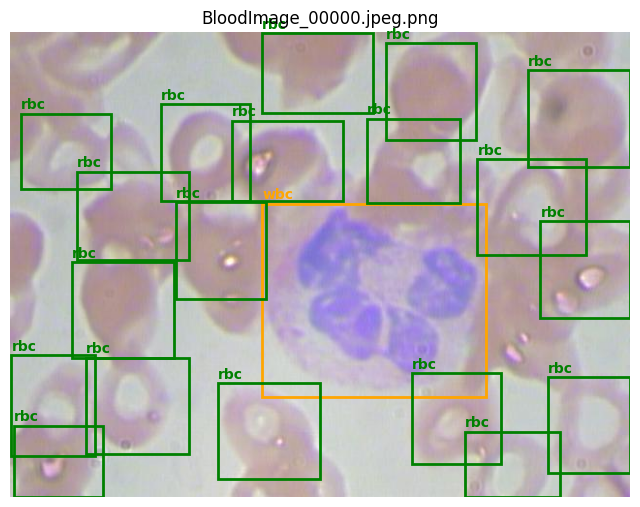

In [12]:
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path

# Đường dẫn
CSV_PATH = "dataset/BDDC/annotations_eval.csv"
IMAGE_DIR = "dataset/BDDC/val/img"

# Màu cho từng class
COLORS = {"rbc": "green", "wbc": "orange", "platelets": "red"}

# Đọc CSV
df = pd.read_csv(CSV_PATH)
df.columns = df.columns.str.strip().str.lower()

# Lấy ảnh đầu tiên có annotation
first_img = df["image"].iloc[0]
boxes = df[df["image"] == first_img][["xmin","ymin","xmax","ymax","label"]].values

# Đọc ảnh
img_path = Path(IMAGE_DIR) / first_img[:-3]
img = cv2.imread(str(img_path))
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Vẽ
fig, ax = plt.subplots(figsize=(8,8))
ax.imshow(img_rgb)
ax.set_title(first_img)
ax.axis("off")

for xmin, ymin, xmax, ymax, label in boxes:
    rect = patches.Rectangle((xmin, ymin), xmax-xmin, ymax-ymin,
                             linewidth=2, edgecolor=COLORS.get(label, "blue"),
                             facecolor="none")
    ax.add_patch(rect)
    ax.text(xmin, ymin-5, label, color=COLORS.get(label, "blue"),
            fontsize=10, weight="bold")

plt.show()